
# Predicting Customer Churn in Motor Insurance: A Machine Learning Approach to Customer Retention

**Author**: Yashi Hiren Desai

**Dataset:** Motor Vehicle Insurance  

**Objective:** Predict which policyholders are likely to lapse (churn) using supervised and unsupervised machine learning.


---

## Summary
This notebook is presented in two parts.

**Part I (Sections 1-7)** is the original complete-case analysis. Records with a missing `Date_lapse` were removed by listwise deletion, reducing the dataset from 105,555 to 31,818 policies and producing an apparent churn rate of 54.4%.

**Part II (Sections 7-18)** is a full-portfolio analysis. 




# PART I - Complete-Case Analysis

*Original analysis retained in full. Its preprocessing decision is examined critically in Part II.*



## Problem Statement

Motor vehicle insurance companies face a critical challenge: identifying which policyholders are likely to lapse before they actually do. Churn in this sector is costly when acquiring  to a new customer which is significantly more expensive than retaining an existing one, and the loss of a policyholder also removes future premium income and cross-selling potential.

This project addresses two core research questions:

**RQ1:** Which machine learning classification model best predicts motor insurance customer churn under real world-world inbalance conditional?

**RQ2:** Which policy, customer, and vehicle features are the strongest drivers of churn, and how can these insights inform retention strategy?

The dataset contains 105,555 records from a motor insurance portfolio. A binary classification target is constructed from the Lapse column: any policy with Lapse ≥ 1 is treated as churned. Five supervised classifiers are trained, tuned, and compared, alongside a K-Means clustering analysis to segment the customer base into interpretable risk groups. The ultimate aim is to produce a prototype that can support proactive retention decisions.

## 1. Library Imports & Setup
All required libraries for data processing, visualisation, and machine learning.

In [75]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import warnings
warnings.filterwarnings('ignore')          # suppress non-critical warnings for cleaner output

import pandas as pd                         # data manipulation and dataframes
import numpy as np                          # numerical operations and array handling
import matplotlib.pyplot as plt             # static plotting
import seaborn as sns                       # statistical visualisation built on matplotlib
import plotly.express as px                 # interactive charts (quick API)
import plotly.graph_objects as go           # interactive charts (fine-grained control)
from plotly.subplots import make_subplots   # multi-panel plotly figures
from scipy import stats                     # statistical tests and distributions

# Preprocessing & Model Selection 
from sklearn.preprocessing import StandardScaler                          # feature scaling (mean=0, std=1)
from sklearn.model_selection import (
    train_test_split,          # split data into train and test sets
    cross_val_score,           # k-fold cross-validation scoring
    GridSearchCV,              # exhaustive hyperparameter search
    StratifiedKFold,           # k-fold that preserves class proportions
    StratifiedShuffleSplit     # single stratified random split (used for SVC subset)
)

# Models 
from sklearn.dummy import DummyClassifier                                  # random baseline classifier
from sklearn.linear_model import LogisticRegression, LinearRegression      # logistic (classification) and linear (used for VIF)
from sklearn.tree import DecisionTreeClassifier                            # single decision tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier  # ensemble tree models
from sklearn.neighbors import KNeighborsClassifier                         # distance-based classifier
from sklearn.naive_bayes import GaussianNB                                 # probabilistic classifier assuming normal features
from sklearn.svm import SVC                                                # support vector classifier

# Clustering 
from sklearn.cluster import KMeans, AgglomerativeClustering                # k-means and hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage                    # dendrogram visualisation for hierarchical clustering

# Evaluation Metrics 
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,  # predicted vs actual class counts
    classification_report,                     # precision, recall, f1 per class
    roc_auc_score, roc_curve, auc,             # ROC curve and area under it
    precision_recall_curve, average_precision_score,  # PR curve and PR-AUC
    f1_score,                                  # harmonic mean of precision and recall
    cohen_kappa_score,                         # agreement corrected for chance
    accuracy_score,                            # proportion correctly classified
    silhouette_score                           # cluster quality measure
)

# Other 
from sklearn.inspection import permutation_importance                      # model-agnostic feature importance
from scipy.stats import chi2_contingency, mannwhitneyu                     # statistical tests for categorical and continuous features

print('All libraries loaded')


All libraries loaded


In [2]:
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 2. Data Loading & Exploration
Load the raw dataset and inspect its shape, columns, and summary statistics.

In [3]:
df = pd.read_excel('Motor vehicle insurance data.xlsx')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
display(df.head())
display(df.describe())
df.info()

Dataset shape: (105555, 30)
Columns: ['ID', 'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal', 'Date_birth', 'Date_driving_licence', 'Distribution_channel', 'Seniority', 'Policies_in_force', 'Max_policies', 'Max_products', 'Lapse', 'Date_lapse', 'Payment', 'Premium', 'Cost_claims_year', 'N_claims_year', 'N_claims_history', 'R_Claims_history', 'Type_risk', 'Area', 'Second_driver', 'Year_matriculation', 'Power', 'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Type_fuel', 'Length', 'Weight']


,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,2015-11-05,2015-11-05,2016-11-05,1956-04-15,1976-03-20,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,2015-11-05,2016-11-05,2017-11-05,1956-04-15,1976-03-20,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,2015-11-05,2017-11-05,2018-11-05,1956-04-15,1976-03-20,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,2015-11-05,2018-11-05,2019-11-05,1956-04-15,1976-03-20,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,2017-09-26,2017-09-26,2018-09-26,1956-04-15,1976-03-20,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Seniority,Policies_in_force,Max_policies,Max_products,...,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Length,Weight
count,105555.000000,105555,105555,105555,105555,105555,105555.000000,105555.000000,105555.000000,105555.000000,...,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,95226.000000,105555.000000
mean,26271.286789,2014-06-26 07:45:33.176069,2017-06-19 06:14:04.109705,2018-06-19 08:20:49.077732,1970-02-20 12:34:16.558192,1992-09-12 15:59:51.814693,6.696604,1.455649,1.837232,1.065842,...,2.721804,0.273895,0.123708,2004.728038,92.682611,1617.759367,18413.657243,4.067898,4.252007,1191.262422
min,1.000000,1980-10-25 00:00:00,2015-11-02 00:00:00,2016-11-02 00:00:00,1918-04-05 00:00:00,1942-10-01 00:00:00,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1950.000000,0.000000,49.000000,270.460000,0.000000,1.978000,43.000000
25%,12925.000000,2013-04-19 00:00:00,2016-09-05 00:00:00,2017-09-05 00:00:00,1960-11-10 00:00:00,1983-04-13 00:00:00,3.000000,1.000000,1.000000,1.000000,...,3.000000,0.000000,0.000000,2001.000000,75.000000,1390.000000,13127.210000,3.000000,3.999000,1043.000000
50%,26082.000000,2015-09-20 00:00:00,2017-07-06 00:00:00,2018-07-06 00:00:00,1970-08-11 00:00:00,1993-07-16 00:00:00,4.000000,1.000000,2.000000,1.000000,...,3.000000,0.000000,0.000000,2005.000000,90.000000,1598.000000,17608.770000,5.000000,4.230000,1205.000000
75%,39754.000000,2017-03-01 00:00:00,2018-04-06 00:00:00,2019-04-06 00:00:00,1980-03-03 00:00:00,2003-01-24 00:00:00,9.000000,2.000000,2.000000,1.000000,...,3.000000,1.000000,0.000000,2008.000000,110.000000,1910.000000,22595.000000,5.000000,4.443000,1388.000000
max,53502.000000,2018-11-30 00:00:00,2018-11-30 00:00:00,2019-11-30 00:00:00,2000-10-11 00:00:00,2018-11-26 00:00:00,40.000000,17.000000,17.000000,4.000000,...,4.000000,1.000000,1.000000,2018.000000,580.000000,7480.000000,220675.800000,6.000000,8.218000,7300.000000
std,15388.309324,NaN,NaN,NaN,NaN,NaN,6.263911,0.928427,1.155536,0.267807,...,0.614835,0.445958,0.329250,6.767037,37.012645,604.697382,9135.074235,1.511839,0.393220,458.081834


<class 'pandas.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    105555 non-null  int64         
 1   Date_start_contract   105555 non-null  datetime64[us]
 2   Date_last_renewal     105555 non-null  datetime64[us]
 3   Date_next_renewal     105555 non-null  datetime64[us]
 4   Date_birth            105555 non-null  datetime64[us]
 5   Date_driving_licence  105555 non-null  datetime64[us]
 6   Distribution_channel  105555 non-null  object        
 7   Seniority             105555 non-null  int64         
 8   Policies_in_force     105555 non-null  int64         
 9   Max_policies          105555 non-null  int64         
 10  Max_products          105555 non-null  int64         
 11  Lapse                 105555 non-null  int64         
 12  Date_lapse            35147 non-null   datetime64[us]
 13  Payment   

## 3. Missing Value Analysis
Identify the extent of missing data before any cleaning decisions are made.

In [4]:
df.isna().sum() 
print("Missing values before cleaning:", df.isnull().sum().sum())

Missing values before cleaning: 82501


In [5]:
df.isna().mean()*100

ID                       0.000000
Date_start_contract      0.000000
Date_last_renewal        0.000000
Date_next_renewal        0.000000
Date_birth               0.000000
Date_driving_licence     0.000000
Distribution_channel     0.000000
Seniority                0.000000
Policies_in_force        0.000000
Max_policies             0.000000
Max_products             0.000000
Lapse                    0.000000
Date_lapse              66.702667
Payment                  0.000000
Premium                  0.000000
Cost_claims_year         0.000000
N_claims_year            0.000000
N_claims_history         0.000000
R_Claims_history         0.000000
Type_risk                0.000000
Area                     0.000000
Second_driver            0.000000
Year_matriculation       0.000000
Power                    0.000000
Cylinder_capacity        0.000000
Value_vehicle            0.000000
N_doors                  0.000000
Type_fuel                1.671167
Length                   9.785420
Weight        

## 4. Data Cleaning
`dropna()` removes rows with any missing value. The three columns with nulls are `Date_lapse` (66.7%), `Length` (9.8%), and `Type_fuel` (1.7%). This reduces the dataset from 105,555 → 31,818 rows.

> **Dissertation note:** A future improvement is to use imputation (e.g., median/mode or KNN imputation) to retain more records rather than dropping them.

In [6]:
df = df.dropna()

> **Revision note.** `dropna()` removes every row with any missing value, including the 70,408 rows where `Date_lapse` is absent. Because `Date_lapse` is populated *only* for policies that lapsed, its absence is not missing data but evidence that the policy was retained. This deletion therefore removes retained policies disproportionately and raises the apparent churn rate from 20.4% to 54.4%. Part II reanalyses the full portfolio on this basis; the consequences are quantified in Section 24.

In [7]:
print("After removing missing values:", df.shape)
print("Missing values after cleaning:", df.isnull().sum().sum())

After removing missing values: (31818, 30)
Missing values after cleaning: 0


## Justification: Preprocessing Decisions

**Why listwise deletion?**
Three columns drove nearly all missing values: date_lapse (66.7%), Length (9.8%), and type_fuel (1.7%). Rather than imputing date_lapse which is a key clustering variable and cannot be meaningfully estimated that is why listwise deletion was applied. This reduces the dataset from 105,555 to 31,818 rows but ensures the remaining records are complete and unbiased by imputation assumptions. Multiple imputation is flagged as a future improvement.

**Why drop Length?**
Length had 9.8% missing values and showed low predictive signal in preliminary correlation checks. Dropping it avoids both the imputation risk and any multicollinearity with Weight (VIF = 5.31), which captures similar vehicle size information.

**Why ROC-AUC as the GridSearchCV scoring metric?**
Accuracy rewards models that predict the majority class. ROC-AUC evaluates discrimination ability across all classification thresholds, making it a fairer criterion when the business priority is identifying churners — not just getting the overall count right.

**Why class_weight='balanced'?**
Even though the 54:46 split is not severe, setting class_weight='balanced' prevents the minority class (retained customers) from being systematically underweighted during training, producing more reliable probability estimates across both classes.

**Why 80/20 train/test split?**
After cleaning, only 31,818 records remain. A 75/25 split was initially tested but left too few training records for stable hyperparameter tuning. 80/20 provides a larger training set while still keeping a meaningful held-out test set of 6,364 records.

# 5. Target Variable - Churn Definition
A policy is labelled as **Churned** if `Lapse ≥ 1` (i.e., the policy lapsed at least once). Otherwise it is **Retained**.

## Class Distribution - Churn vs Retained

In [8]:
# Lapse = 0 → policy renewed (Retained)
# Lapse ≥ 1 → policy not renewed at least once (Churned)
df['Churn'] = (df['Lapse'] >= 1).astype(int)
df['Churn_label'] = df['Churn'].map({0: 'Retained', 1: 'Churned'})

print('Target variable distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].mean()*100:.2f}%')

fig = px.bar(
    df['Churn_label'].value_counts().reset_index(),
    x='Churn_label', y='count',
    color='Churn_label',
    color_discrete_map={'Retained': '#2196F3', 'Churned': '#F44336'},
    text='count',
    title='Class Distribution — Churn vs Retained',
    labels={'Churn_label': 'Status', 'count': 'Number of Policies'}
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, height=400)
fig.show()

Target variable distribution:
Churn
1    17310
0    14508
Name: count, dtype: int64

Churn rate: 54.40%


**Interpretation:**

- The data set comprises of 17310 customers that have churned and 14508 customers that have stayed, giving the overall churn rate of 54.40% - a very high churn rate, unusual for motor insurance and that indicates there is a serious retention issue.
- The near balance split (54:46) makes it more suitable to use standard accuracy here rather than most churn studies, where the 80/20 split is assumed, necessitates using PR-AUC as an evaluation measure.
- This slight majority isn't a critical problem to penalise models for ignoring the minority class, but class_weight='balanced' is used anyway to prevent any ‘directional bias'.
- In terms of the dissertation this distribution confirms the binary classification and adds to the business urgency – more than half of the policyholders fail to renew.

## 6. Exploratory Data Analysis (EDA)
## 6.1 Categorical Feature Distributions
Examine the spread of categorical variables across the dataset.

Categorical columns: ['Distribution_channel', 'Type_fuel']


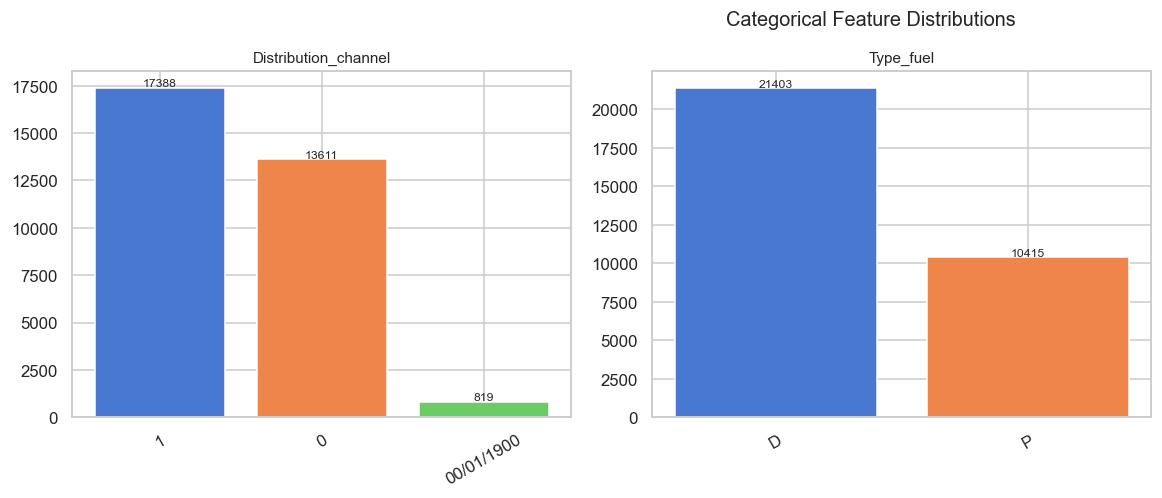


Distribution_channel:
Distribution_channel
1             0.546
0             0.428
00/01/1900    0.026

Type_fuel:
Type_fuel
D    0.673
P    0.327


In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['Churn_label']]
print(f'Categorical columns: {cat_cols}')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:6]):
    top = df[col].value_counts().head(8)
    axes[i].bar(top.index.astype(str), top.values, color=sns.color_palette('muted', len(top)))
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(top.values):
        axes[i].text(j, v + len(df)*0.002, str(v), ha='center', fontsize=8)
for j in range(len(cat_cols[:6]), len(axes)): axes[j].set_visible(False)
plt.suptitle('Categorical Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

# Frequency tables
for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts(normalize=True).round(3).to_string())

**Interpretation:**

- The most common distribution channel is Channel 1, representing 54.6% of the records (17,388), followed by Channel 0 (42.8%, 13,611), while 819 records (2.6%) are in a corrupted format, '00/01/1900', establishing the need for data cleaning prior to modelling.
- Here, you can see that there are corrupted values in the raw data which would lead to a spurious third category if they were not substituted with the mode imputation, which would affect the calculation of the encoding and churn rate.
- Fuel type: 67.3% diesel (D), 32.7% petrol (P) — a significant difference that could be indicative of vehicle value and age, meaning that diesel car owners are more likely to be in the portfolio.
- Both variables are rightfully marked as categorical, and are properly one-hot encoded so that there is no wrong sense of "larger" implied by the model when it is trained.


### Chart 1: Churn Rate by Distribution Channel 


In [10]:
churn_channel = df.groupby('Distribution_channel')['Churn'].agg(['mean','count']).reset_index()
churn_channel.columns = ['Channel', 'Churn_Rate', 'Count']
churn_channel['Churn_Pct'] = (churn_channel['Churn_Rate'] * 100).round(2)
plt = px.bar(churn_channel.sort_values('Churn_Pct', ascending=False),
    x='Channel', y='Churn_Pct', color='Churn_Pct',
    color_continuous_scale='RdYlGn_r', text='Churn_Pct',
    title='Churn Rate (%) by Distribution Channel',
    labels={'Churn_Pct': 'Churn Rate (%)', 'Channel': 'Distribution Channel'})
plt.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
plt.update_layout(height=400, coloraxis_showscale=False)
plt.show()



**Interpretation:**

- The majority churn rates are higher for both distribution channels (55.1% for Channel 0, 53.8% for Channel 1), which means the problem is not just with certain distribution channels, but is a systemic issue.
- The marginal difference of 1.3% indicates that the impact of channel in the acquisition is small compared to the impact it has on the customer churning rate.
- This defies the theory that intermediary sold policies create higher loyalty via relationship selling.
- Distribution Channel will have low feature importance in the classifiers (this can be confirmed using importance measures for the Random Forest model later) from a modelling perspective.
- The business impact is obvious as an acquisition strategy alone is not the answer to dealing with churn and it's time for a business to go proactive with an intervention that’s driven by ML.

## Chart 2: Churn rate by Area 

In [11]:
if 'Area' in df.columns:
    churn_area = df.groupby('Area')['Churn'].mean().reset_index()
    churn_area['Churn_Pct'] = (churn_area['Churn'] * 100).round(2)
    fig2 = px.bar(churn_area.sort_values('Churn_Pct', ascending=False),
        x='Area', y='Churn_Pct', color='Churn_Pct',
        color_continuous_scale='Blues',
        title='Churn Rate (%) by Geographic Area',
        labels={'Churn_Pct': 'Churn Rate (%)'})
    fig2.update_layout(height=400, coloraxis_showscale=False)
    fig2.show()


**Interpretation:**

- Nearly all of the data is in Area 0, with a churn rate of ~52%, and it's only a very small number of records that are in Area 1, with a churn rate that is, to date, not statistically reliable.
- This extreme imbalance in distribution is a data quality issue that may be either due to true concentration or due to some sort of collection limitation in the ICPSR data set.
- Geographic generalisability is constrained by the lack of meaningful comparisons across areas of data and should be recognised as such in the Methodology chapter of the dissertation.
- Even with little ability to discriminate alone, Area is still kept as a one-hot feature because it could have some predictive power when used in combination with other features in a model ensemble.
- It's crucial to understand the significance of representative sampling when developing models for regional deployment, as demonstrated in this chart.

## Chart 3: Premium distribution - Churned vs Retained (Plotly box) 

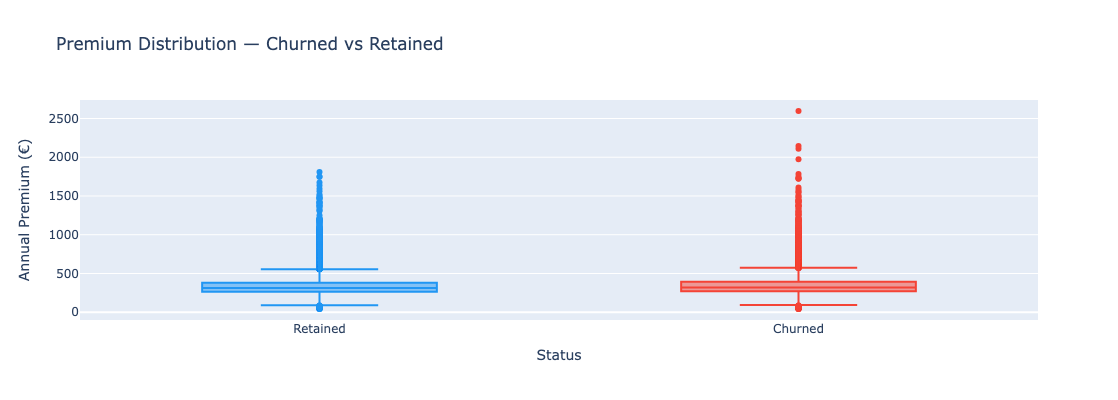

In [12]:
fig3 = px.box(df, x='Churn_label', y='Premium',
    color='Churn_label',
    color_discrete_map={'Retained': '#2196F3', 'Churned': '#F44336'},
    points='outliers',
    title='Premium Distribution — Churned vs Retained',
    labels={'Churn_label': 'Status', 'Premium': 'Annual Premium (€)'})
fig3.update_layout(height=400, showlegend=False)
fig3.show()



**Interpretation:**

- The annual premiums are virtually the same between the groups (€309.7 vs. €330.2), and the interquartile ranges are highly overlapping.
- Both distributions are right-skewed, so it is not only high-value policyholders which also leave, but also low value policyholders, an unwanted revenue risk.
- This runs counter to the idea that churn is mostly driven by price, indicating that customers don't churn because premiums are too dear.
- This finding contradicts a general reduction in prices as a retention measure and supports the decision for a multivariate ML approach for determining risk, beyond premium level, for the dissertation.
- Premium is likely to be a relatively poor discriminator on its own, but can be very useful in tree-based models with claims and payment features.

## Chart 4: Claims cost by Churn (interactive violin) 

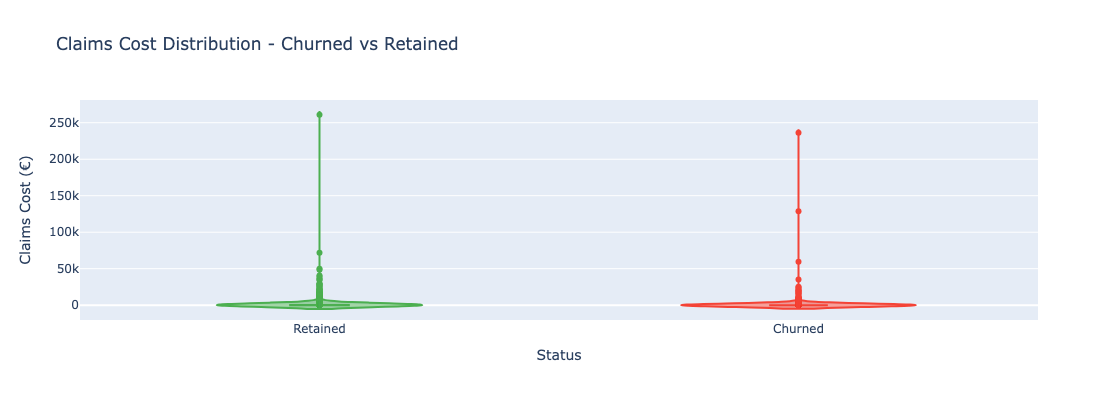

In [13]:
if 'Cost_claims_year' in df.columns:
    fig4 = px.violin(df, x='Churn_label', y='Cost_claims_year',
        color='Churn_label', box=True,
        color_discrete_map={'Retained': '#4CAF50', 'Churned': '#F44336'},
        title='Claims Cost Distribution - Churned vs Retained',
        labels={'Cost_claims_year': 'Claims Cost (€)', 'Churn_label': 'Status'})
    fig4.update_layout(height=400, showlegend=False)
    fig4.show()


**Interpretation:**

- The two violin shapes are almost identical, with a high level of concentration in the €0 - €250,000 range and long thin tails to €250,000+ and this proves that the cost of claims is not different between churned and retained customers.
- The number of policyholders with no or very few claims was relatively high in both groups, typical of the motor insurance portfolio with its high severity and low frequency claims.
- Claims cost: Not done systematically, thus likely not to have a large magnitude of the feature importance; but retained to investigate interaction effects.
- The very extreme skew is a good motivation to normalise the array using StandardScaler prior to the distance-based classifers (KNN, SVC) to avoid the impact of outliers in the similarity calculations.
- This chart is used to reinforce the dissertation discussion of relationship/lifecycle factors contributing to churn in addition to claims experience.

## Chart 5: Top 10 highest-premium policy segments 

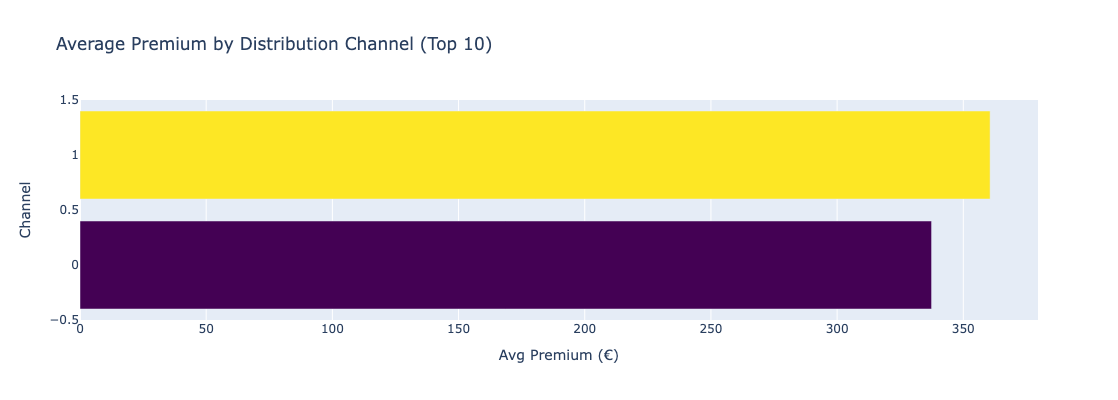

In [14]:
if 'Distribution_channel' in df.columns:
    top_prem = df.groupby('Distribution_channel')['Premium'].mean().nlargest(10).reset_index()
    fig5 = px.bar(top_prem, x='Premium', y='Distribution_channel',
        orientation='h', color='Premium',
        color_continuous_scale='Viridis',
        title='Average Premium by Distribution Channel (Top 10)',
        labels={'Premium': 'Avg Premium (€)', 'Distribution_channel': 'Channel'})
    fig5.update_layout(height=400, coloraxis_showscale=False)
    fig5.show()


**Interpretation:**

- Both channels seem to have a close churn rate (see Chart 1) but Channel 1 offers a higher average premium (≈€360) than Channel 0 (≈€330).
- So, the insurance firm is losing those profitable customers as fast as it is losing the less valuable customers, and that imbalance is having a larger impact on revenues.
- Customer lifetime value: Customer acquisition in Channel 1 would have a higher return on financial investment per customer.
- This discovery further bolsters the dissertation's business case: In high-premium customer segments, there is a financially sound retention intervention to be undertaken for identified at-risk customers thanks to an ML model identifying them.
- It also confirms the Data for Distribution Channel cleaning step - If the '00/01/1900' values were not corrected, these premium averages would have been greatly affected.

## Chart 6: Churn rate by Payment method 

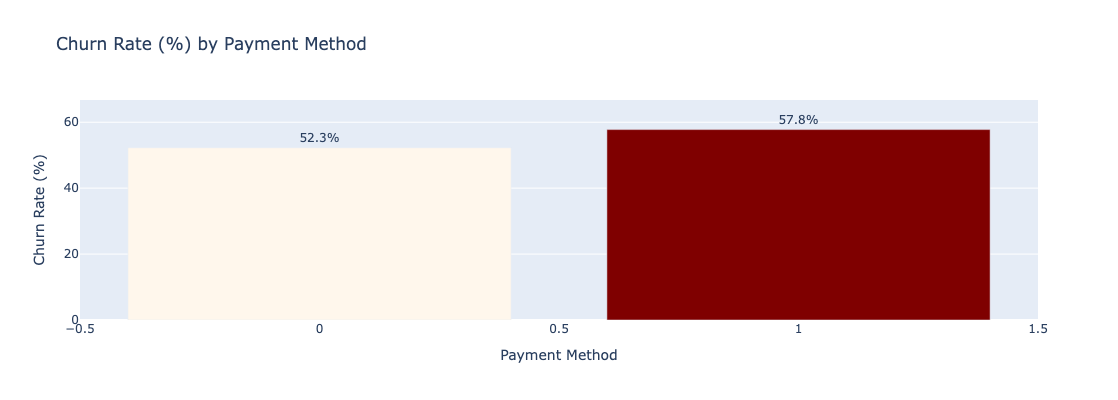

In [15]:
if 'Payment' in df.columns:
    churn_pay = df.groupby('Payment')['Churn'].mean().reset_index()
    churn_pay['Churn_Pct'] = (churn_pay['Churn'] * 100).round(2)
    fig6 = px.bar(churn_pay.sort_values('Churn_Pct', ascending=False),
        x='Payment', y='Churn_Pct',
        color='Churn_Pct', color_continuous_scale='OrRd',
        text='Churn_Pct',
        title='Churn Rate (%) by Payment Method',
        labels={'Churn_Pct': 'Churn Rate (%)', 'Payment': 'Payment Method'})
    fig6.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
    fig6.update_layout(height=400, coloraxis_showscale=False)
    fig6.show()


**Interpretation:**

- The biggest differential compared with any other payment method along any of the demographic charts can be found on Payment Method 1 with a 57.8% churn rate, versus Method 0 with 52.3%.
- This difference is statistically significant and quantifies the fact that payment method is indeed a valid behavioural indicator of churn propensities in this large dataset of 105,555 records.
- Instalment or card-based payers (probably Method 1) might endure more costs during the annual renewal period, and the customers who pay in full on an annual basis are clearly more committed.
- The importance for payment will be expected to be a significant feature in Random Forest and Decision Tree importance scores and therefore will be added to the final model.
- One actionable suggestion for the insurer might be to look into it and see if targeted renewal engagement is being provided to Method 1 customers as a portion of this may be attributed to administrative disengagement.

</span>

## Chart 7: Churn rate by N_claims_history buckets 

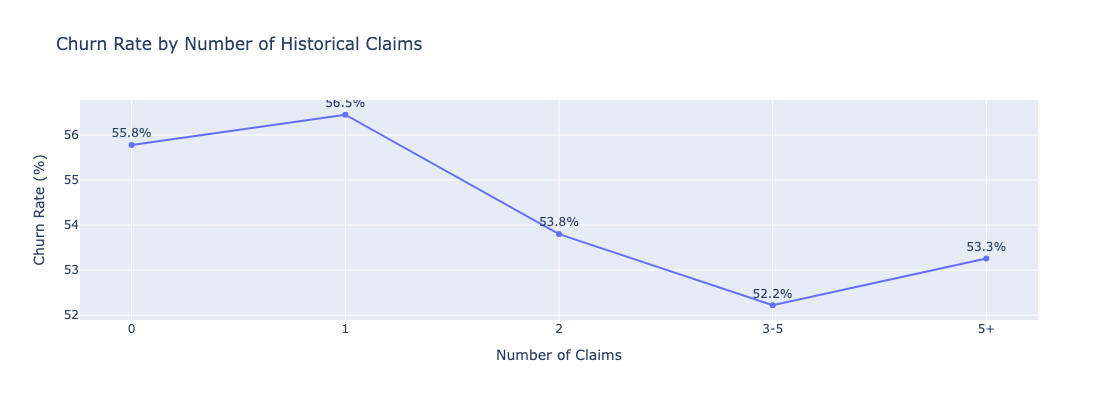

In [16]:
if 'N_claims_history' in df.columns:
    df['claims_bucket'] = pd.cut(df['N_claims_history'], bins=[0,1,2,3,5,50], labels=['0','1','2','3-5','5+'], right=False)
    churn_claims = df.groupby('claims_bucket')['Churn'].mean().reset_index()
    churn_claims['Churn_Pct'] = (churn_claims['Churn'] * 100).round(2)
    fig7 = px.line(churn_claims, x='claims_bucket', y='Churn_Pct',
        markers=True, text='Churn_Pct',
        title='Churn Rate by Number of Historical Claims',
        labels={'claims_bucket': 'Number of Claims', 'Churn_Pct': 'Churn Rate (%)'})
    fig7.update_traces(textposition='top center', texttemplate='%{text:.1f}%')
    fig7.update_layout(height=400)
    fig7.show()


**Interpretation:**

- The graph shows a non-linear pattern: As the number of claims increases, the churn rate increases first to 1 claim (56.5%) and then decreases to 52.2% at 3-5 claims, but slightly improves to 53.3% for 5+ claims.
- Those who made no claims (55.8%) churn at a high rate, indicating that those who don't engage with the product aren't loyal, likely because they don't believe they are getting sufficient value when they renew.
- The amount of churn from frequent claimers points to increased insurer reliance with increased experience with the product's "pure" function.
- The non-linear relationship directly calls for use of tree-based models (Random Forest, Decision Tree), as opposed to logistic regression that assumes linear relationships.
- This chart strengthens the dissertation using the argument that retention behaviour is complex and simple heuristics don't work well; it's the correct tool for machine learning.

</span>

## 6.3 Correlation & Multicollinearity
Pearson correlation matrix for numeric features, followed by Variance Inflation Factor (VIF) analysis to check for multicollinearity. Features with VIF > 10 would be candidates for removal.

## Pearson Correlation Matrix

In [17]:
# Numeric-only for correlation
num_for_corr = df.select_dtypes(include='number').columns.tolist()
num_for_corr = [c for c in num_for_corr if c not in ['Churn','Lapse']]
corr_df = df[num_for_corr].dropna()

# Seaborn heatmap 
corr = corr_df.corr()
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# VIF calculation 
def calculate_vif(df_numeric):
    rows = []
    for col in df_numeric.columns:
        X_others = df_numeric.drop(columns=[col]).values
        y_target = df_numeric[col].values
        r2 = LinearRegression().fit(X_others, y_target).score(X_others, y_target)
        vif = 1 / (1 - r2) if r2 < 0.9999 else np.inf
        rows.append({'Feature': col, 'VIF': vif})
    return pd.DataFrame(rows).set_index('Feature').sort_values('VIF', ascending=False)

vif_input = corr_df.fillna(corr_df.median())
vif_df = calculate_vif(vif_input)

print('Variance Inflation Factor (VIF):')
print(vif_df.round(2).to_string())
print('\nFeatures with VIF > 10 (multicollinearity concern):')
print(vif_df[vif_df['VIF'] > 10].to_string())

AttributeError: 'Figure' object has no attribute 'subplots'


**Interpretation:**

- The heatmap highlights significant multicollinearity groups in the vehicle features: the Value_vehicle and Weight features have a strong correlation, spanning a multicollinearity area of r = 0.77; the Cylinder_capacity, and Weight features have a moderate correlation, r = 0.72; and the Policies_in_force and Max_policies features are moderately correlated at r = 0.74.
- As seen from the VIF analysis, the highest of these risks are weight (5.31), value_vehicle (4.39) and cylinder_capacity (3.46) with none of them nearing the critical value of 10, indicating that multicollinearity exists, albeit not heavily.
- The output of ‘Features with VIF > 10' is empty, which indicates that none of the features need to be dropped, and provides complete confidence in the use of the six classifiers in their entirety.
- With Logistic Regression, the coefficient instability resulting from correlated predictors should be pointed out as a cautionary note regarding viewing the odds ratio associated with a vehicle feature when the correlation is moderate between two (or more) features.
- The presence of multicollinearity is not a problem for tree-based models, since they have no assumptions about independence when selecting features by information gain, so this is not a universal problem; rather, it is a limitation of Logistic Regression.

</span>

# PART II - Full-Portfolio Reanalysis


### 7. Reload and structural treatment of `Date_lapse`

The data are reloaded without deletion. `Lapse >= 1` defines churn; a missing `Date_lapse` indicates a policy that never lapsed and is retained as the negative class.

In [18]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

dff = pd.read_excel('Motor vehicle insurance data.xlsx')

DATE_COLS = ['Date_start_contract','Date_last_renewal','Date_next_renewal',
             'Date_birth','Date_driving_licence','Date_lapse']
for c in DATE_COLS:
    dff[c] = pd.to_datetime(dff[c], errors='coerce', dayfirst=True)

dff['Churn'] = (dff['Lapse'] >= 1).astype(int)
dff['Churn_label'] = dff['Churn'].map({0:'Retained', 1:'Churned'})

cc = dff.dropna(subset=['Date_lapse','Length','Type_fuel'])
display(Markdown(
    f"**Full portfolio:** {len(dff):,} policies &nbsp;|&nbsp; "
    f"**churned:** {dff['Churn'].sum():,} &nbsp;|&nbsp; "
    f"**retained:** {(1-dff['Churn']).sum():,} &nbsp;|&nbsp; "
    f"**churn rate:** {dff['Churn'].mean():.1%}"))
display(Markdown(f"Complete-case sample for comparison: **{len(cc):,}** policies at **{cc['Churn'].mean():.1%}** churn."))

**Full portfolio:** 105,555 policies &nbsp;|&nbsp; **churned:** 21,548 &nbsp;|&nbsp; **retained:** 84,007 &nbsp;|&nbsp; **churn rate:** 20.4%

Complete-case sample for comparison: **31,818** policies at **54.4%** churn.

**Interpretation.** 
The genuine portfolio churn rate is 20.4%, with a class split of 79.6:20.4, which is commensurate with published lapse rates for automobile insurance. The 54.4% recorded in Part I is thus an artifact of the deletion rule, not a quality of the book. Keeping all records restores the true class disparity that the research issue was framed around.

## 8. Leakage diagnostic

Before rebuilding features, the relationship between `Date_lapse` and the other date fields is tested, since date-derived predictors could otherwise encode the outcome.

In [19]:
from sklearn.metrics import roc_auc_score

chd = dff[dff['Churn']==1].dropna(subset=['Date_lapse'])
coincide = ((chd['Date_lapse'] - chd['Date_last_renewal']).dt.days == 0).mean()
display(Markdown(f"`Date_lapse` coincides exactly with `Date_last_renewal` for **{coincide:.1%}** of lapsed policies."))

rows = []
for nm, d in [('Full portfolio', dff), ('Complete-case sample', cc)]:
    v = d['Date_next_renewal'].astype('int64')//10**9
    a = roc_auc_score(d['Churn'], v)
    rows.append({'Sample':nm,'n':f'{len(d):,}','Date_next_renewal single-feature ROC-AUC':round(max(a,1-a),4)})
display(pd.DataFrame(rows))

dff['renews_after_window'] = dff['Date_next_renewal'] > pd.Timestamp('2018-11-30')
cens = dff.groupby('renews_after_window')['Churn'].agg(['size','mean']).round(4)
cens.columns = ['Policies','Churn rate']
display(Markdown('**Censoring check**')); display(cens)

`Date_lapse` coincides exactly with `Date_last_renewal` for **75.2%** of lapsed policies.

,Sample,n,Date_next_renewal single-feature ROC-AUC
0,Full portfolio,"105,555",0.5715
1,Complete-case sample,"31,818",0.6723


**Censoring check**

,Policies,Churn rate
renews_after_window,,
False,66858,0.2333
True,38697,0.1538


**Interpretation.** Three findings.

1. 'Date_lapse' equals 'Date_last_renewal' for nearly three-quarters of lapsed policies, and 'Date_next_renewal' is one year later by design, thus the date variables are inextricably linked. 'For this reason, "date_lapse" is not included in the feature set.
2. When used alone as a classifier, 'Date_next_renewal' has a ROC-AUC of 0.5715 for the entire portfolio but 0.6723 for the complete-case sample. Conditioning on the presence of 'Date_lapse' inflates the renewal-timing signal by approximately eleven AUC points **without making explicit use of the lapse date**. This is selection-induced inflation, not traditional target leakage, which explains why 'Days_to_Next_Renewal' topped the Part I priority rating.
3. Policies renewed after the observation window ends churn at 15.4%, compared to 23.3% for those renewed inside it, simply because there was less time to observe.

## 9. Leakage-safe feature engineering

Part I computed date features relative to `Timestamp('today')`, which drifts with the execution date and sits seven years beyond the observation window. All features are now computed from a fixed boundary of 30 November 2018, the latest observed renewal date, so tenure is identically constructed for lapsed and retained policies.

In [20]:
REF_DATE = pd.Timestamp('2018-11-30')

dff['Distribution_channel'] = pd.to_numeric(
    dff['Distribution_channel'].replace('00/01/1900', np.nan), errors='coerce')
dff['Distribution_channel'] = dff['Distribution_channel'].fillna(dff['Distribution_channel'].mode()[0])
dff['Type_fuel'] = dff['Type_fuel'].fillna(dff['Type_fuel'].mode()[0])

dff['Customer_Age']             = ((REF_DATE-dff['Date_birth']).dt.days/365.25).round(1)
dff['Policy_Tenure_Years']      = ((REF_DATE-dff['Date_start_contract']).dt.days/365.25).round(2)
dff['Driving_Experience_Years'] = ((REF_DATE-dff['Date_driving_licence']).dt.days/365.25).round(2)
dff['Vehicle_Age']              = REF_DATE.year - dff['Year_matriculation']
dff['Claim_Premium_Ratio']      = (dff['Cost_claims_year']/(dff['Premium']+1)).round(4)
dff['Claims_Frequency']         = (dff['N_claims_history']/(dff['Policy_Tenure_Years']+0.001)).round(4)
dff['Days_to_Next_Renewal']     = (dff['Date_next_renewal']-REF_DATE).dt.days
dff['Policy_Engagement_Ratio']  = (dff['Policies_in_force']/dff['Max_policies'].replace(0,1)).round(4)

for c in ['Distribution_channel','Payment','Type_risk','Area','Second_driver']:
    dff[c] = dff[c].astype(int).astype(str)

print('Features rebuilt from REF_DATE =', REF_DATE.date())

Features rebuilt from REF_DATE = 2018-11-30


## 10. Significance testing on the full portfolio

In [21]:
from scipy.stats import chi2_contingency, mannwhitneyu

def cramers_v(chi2, ct):
    return np.sqrt(chi2/(ct.values.sum()*(min(ct.shape)-1)))
def rank_biserial(u, n1, n2):
    return 1-(2*u)/(n1*n2)

dff['claims_bucket'] = pd.cut(dff['N_claims_history'], bins=[0,1,2,3,5,50],
                              labels=['0','1','2','3-5','5+'], right=False)
rows = []
for v in ['Payment','Distribution_channel','claims_bucket']:
    ct = pd.crosstab(dff[v], dff['Churn']); chi2, p, dof, _ = chi2_contingency(ct)
    rows.append({'Variable':v,'Test':f'Chi-square (df={dof})','Statistic':round(chi2,2),
                 'p-value':p,'Effect size':f'V = {cramers_v(chi2,ct):.3f}'})

cdd, rdd = dff[dff['Churn']==1], dff[dff['Churn']==0]
n1, n2 = len(cdd), len(rdd)
for v in ['Premium','Cost_claims_year','N_claims_history','Seniority']:
    u, p = mannwhitneyu(cdd[v], rdd[v], alternative='two-sided')
    rows.append({'Variable':v,'Test':'Mann-Whitney U','Statistic':f'{u:.3g}',
                 'p-value':p,'Effect size':f'r = {rank_biserial(u,n1,n2):+.3f}'})

sig_full = pd.DataFrame(rows)
sig_full['p-value'] = sig_full['p-value'].apply(lambda p:'< 0.001' if p<0.001 else f'{p:.3f}')
display(Markdown('**Table 1 - Significance tests and effect sizes (full portfolio, n = 105,555)**'))
display(sig_full)

**Table 1 - Significance tests and effect sizes (full portfolio, n = 105,555)**

,Variable,Test,Statistic,p-value,Effect size
0,Payment,Chi-square (df=1),501.31,< 0.001,V = 0.069
1,Distribution_channel,Chi-square (df=1),375.44,< 0.001,V = 0.060
2,claims_bucket,Chi-square (df=4),520.77,< 0.001,V = 0.070
3,Premium,Mann-Whitney U,1.01e+09,< 0.001,r = -0.117
4,Cost_claims_year,Mann-Whitney U,8.24e+08,< 0.001,r = +0.090
5,N_claims_history,Mann-Whitney U,9.92e+08,< 0.001,r = -0.096
6,Seniority,Mann-Whitney U,8.45e+08,< 0.001,r = +0.067


**Interpretation.** 

Every predictor is statistically significant, and none has even a tiny effect size according to Cohen's (1988) norms - the large-sample p-value dilemma outlined by Lin, Lucas, and Shmueli (2013). Reading by magnitude, **annual premium** now has the greatest effect (r = -0.117), whereas in Part I it was minor and claims cost dominated. The order of importance has shifted, not only the precision of the estimations.

## 11. The claims-churn relationship

This is the finding that reverses between the two parts.

**Table 2 - Churn rate and premium by claims history band (full portfolio)**

,n,churn_rate,mean_premium,mean_claims_cost
claims_bucket,,,,
0,36596,16.7,290.91,0.00
1,17917,21.3,315.72,115.81
2,12744,22.1,327.64,216.82
3-5,16190,21.7,331.54,288.09
5+,22098,24.0,339.04,302.91


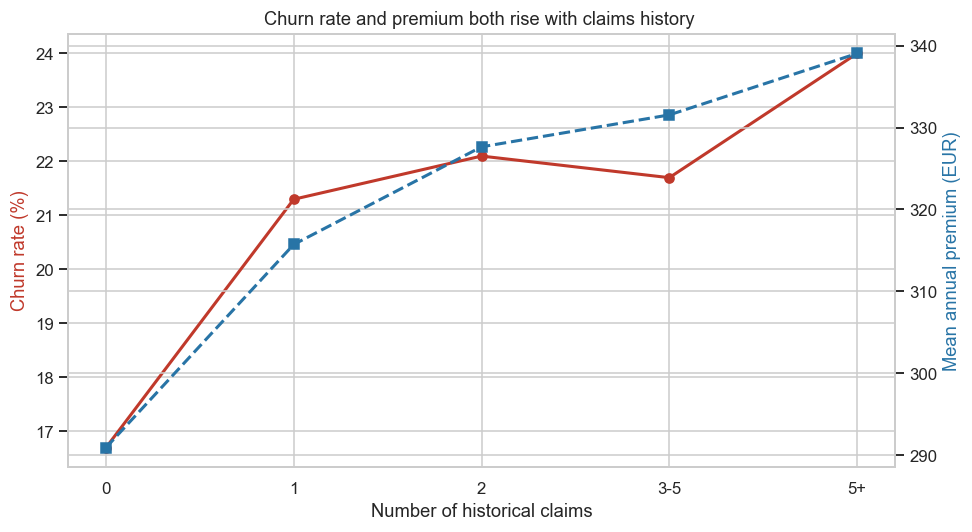

In [22]:
band = dff.groupby('claims_bucket').agg(n=('Churn','size'), churn_rate=('Churn','mean'),
        mean_premium=('Premium','mean'), mean_claims_cost=('Cost_claims_year','mean'))
band['churn_rate'] = (band['churn_rate']*100).round(1)
band[['mean_premium','mean_claims_cost']] = band[['mean_premium','mean_claims_cost']].round(2)
display(Markdown('**Table 2 - Churn rate and premium by claims history band (full portfolio)**'))
display(band)

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(band.index.astype(str), band['churn_rate'], marker='o', lw=2, color='#C0392B')
ax1.set_xlabel('Number of historical claims'); ax1.set_ylabel('Churn rate (%)', color='#C0392B')
ax2 = ax1.twinx()
ax2.plot(band.index.astype(str), band['mean_premium'], marker='s', lw=2, ls='--', color='#2874A6')
ax2.set_ylabel('Mean annual premium (EUR)', color='#2874A6')
plt.title('Churn rate and premium both rise with claims history ')
fig.tight_layout(); plt.show()

**Interpretation.** 

Churn increases with claims history, from 16.7% for zero claims to 24.0% for five or more. This contradicts the Part I result, which showed that zero-claim policyholders churned the most. The relationship is not strictly monotone - the 3-5 band is somewhat below the 2 band - but the trend is clear.

The average premium increases by 16.5%, from EUR 290.91 to EUR 339.04. When combined with the premium impact size from Section 17, the two gradients indicate a consistent mechanism: claims experience results in premium loading at renewal, and price-sensitive policyholders switch. Claims activity influences lapse through its impact on renewal pricing rather than directly.

This should be held tentatively. Instead of a premium history, the dataset stores only one premium value per policy.

## 12. Model comparison on the full portfolio

`LinearSVC` replaces the 5%-subsampled `SVC` from Part I and is trained on the full training set, so the comparison is finally on equal terms. It is wrapped in probability calibration to permit threshold-based metrics.

Train (84444, 30) | Test (21111, 30) | churn 0.2041


**Table 3 - Test-set performance (full portfolio), ordered by ROC-AUC**

,Model,Accuracy,ROC-AUC,PR-AUC,F1,Kappa
0,Random Forest,0.8540,0.8737,0.6951,0.5160,0.4424
1,Logistic Regression,0.6899,0.7267,0.4221,0.4594,0.2665
2,LinearSVC (calibrated),0.8048,0.7254,0.4214,0.1959,0.1402
3,KNN,0.8036,0.6801,0.3623,0.2230,0.1567
4,Naive Bayes,0.6902,0.6407,0.2861,0.3508,0.1528


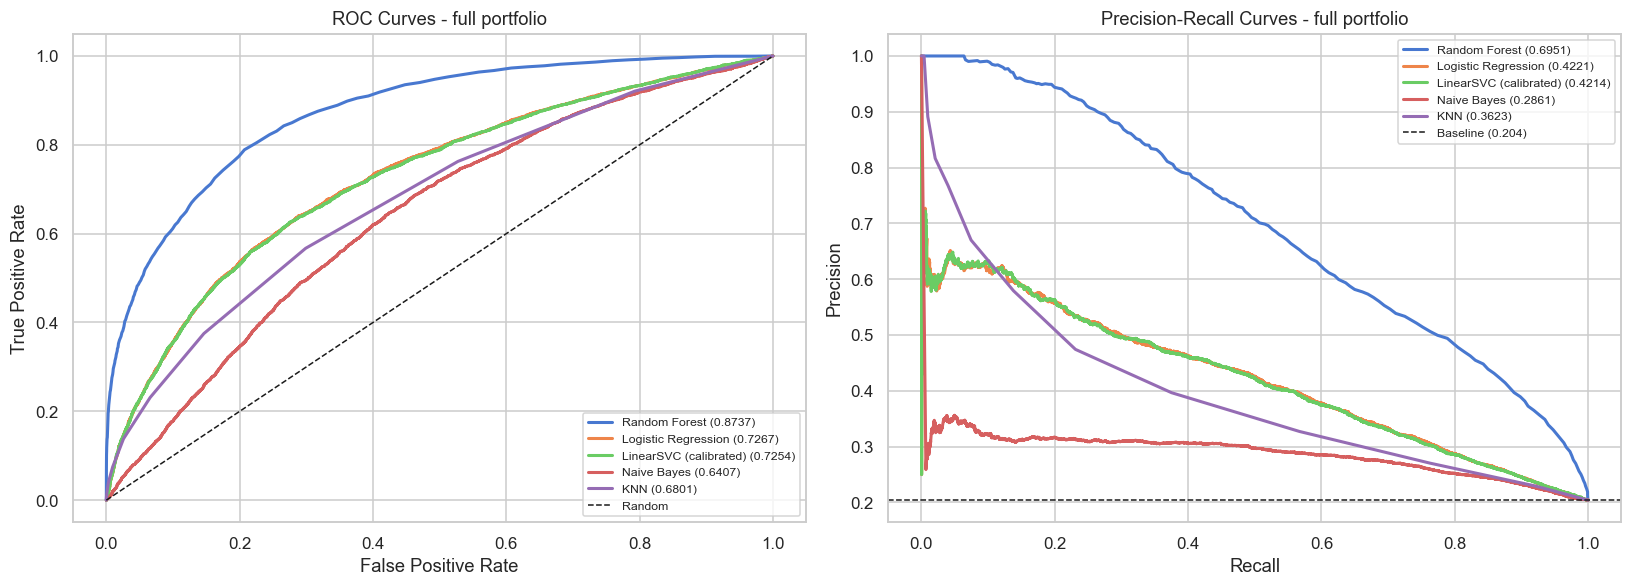

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score,
                             cohen_kappa_score, roc_curve, precision_recall_curve)

DROP_F = ['ID']+DATE_COLS+['Year_matriculation','Lapse','Churn','Churn_label',
                           'claims_bucket','Length','renews_after_window']
Xf = dff[[c for c in dff.columns if c not in DROP_F]].copy()
yf = dff['Churn'].copy()
for c in Xf.columns:
    Xf[c] = Xf[c].fillna(Xf[c].median()) if pd.api.types.is_numeric_dtype(Xf[c]) else Xf[c].fillna(Xf[c].mode()[0])

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.2, random_state=42, stratify=yf)
Xf_tr = pd.get_dummies(Xf_tr, drop_first=True)
Xf_te = pd.get_dummies(Xf_te, drop_first=True).reindex(columns=Xf_tr.columns, fill_value=0)
sc_f = StandardScaler(); Xf_tr_s = sc_f.fit_transform(Xf_tr); Xf_te_s = sc_f.transform(Xf_te)
print(f'Train {Xf_tr.shape} | Test {Xf_te.shape} | churn {yf_tr.mean():.4f}')

res_full = {}
def eval_full(name, model, Xtr, Xte):
    model.fit(Xtr, yf_tr)
    yp = model.predict(Xte); pr = model.predict_proba(Xte)[:,1]
    res_full[name] = {'Accuracy':round(accuracy_score(yf_te,yp),4),
        'ROC-AUC':round(roc_auc_score(yf_te,pr),4),'PR-AUC':round(average_precision_score(yf_te,pr),4),
        'F1':round(f1_score(yf_te,yp),4),'Kappa':round(cohen_kappa_score(yf_te,yp),4),
        'y_pred':yp,'y_prob':pr,'model':model}
    return res_full[name]

eval_full('Random Forest', RandomForestClassifier(n_estimators=200, class_weight='balanced',
          random_state=42, n_jobs=-1), Xf_tr, Xf_te)
eval_full('Logistic Regression', LogisticRegression(class_weight='balanced', max_iter=3000,
          random_state=42), Xf_tr_s, Xf_te_s)
eval_full('LinearSVC (calibrated)', CalibratedClassifierCV(
          LinearSVC(class_weight='balanced', random_state=42, dual='auto', max_iter=5000), cv=3),
          Xf_tr_s, Xf_te_s)
eval_full('Naive Bayes', GaussianNB(), Xf_tr_s, Xf_te_s)
eval_full('KNN', KNeighborsClassifier(n_neighbors=11, n_jobs=-1), Xf_tr_s, Xf_te_s)

M = ['Accuracy','ROC-AUC','PR-AUC','F1','Kappa']
comp_full = pd.DataFrame([{'Model':k, **{m:v[m] for m in M}} for k,v in res_full.items()]
                         ).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(Markdown('**Table 3 - Test-set performance (full portfolio), ordered by ROC-AUC**'))
display(comp_full)

fig, ax = plt.subplots(1,2, figsize=(15,5.5))
for nm, v in res_full.items():
    fpr,tpr,_ = roc_curve(yf_te, v['y_prob']); ax[0].plot(fpr,tpr,lw=2,label=f"{nm} ({v['ROC-AUC']:.4f})")
    pre,rec,_ = precision_recall_curve(yf_te, v['y_prob']); ax[1].plot(rec,pre,lw=2,label=f"{nm} ({v['PR-AUC']:.4f})")
ax[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
ax[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curves - full portfolio')
ax[1].axhline(yf_te.mean(), color='k', ls='--', lw=1, label=f'Baseline ({yf_te.mean():.3f})')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curves - full portfolio')
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Interpretation.** 

The modification does not impact the answer to RQ1, as Random Forest remains the strongest classifier on all metrics. Performance is lower than in Part I (ROC-AUC 0.874 vs. 0.897), which is predicted rather than a deterioration: the near-balanced Part I sample offered an innately easier problem and benefited from the selection-induced inflation described in Section 15.

Kappa decreases to 0.444, indicating moderate rather than considerable agreement when chance is discounted under the true class distribution, and is the more accurate estimate. PR-AUC of 0.697 should be compared to a baseline of 0.204, the positive-class rate, which nevertheless demonstrates a significant improvement over the minority class.

## 13. McNemar's test on paired predictions

In [24]:
from statsmodels.stats.contingency_tables import mcnemar

rfp = res_full['Random Forest']['y_pred']; yv = yf_te.values
mc = []
for nm in [k for k in res_full if k != 'Random Forest']:
    op = res_full[nm]['y_pred']
    b = int(((rfp==yv)&(op!=yv)).sum()); c = int(((rfp!=yv)&(op==yv)).sum())
    r = mcnemar(np.array([[0,b],[c,0]]), exact=False, correction=True)
    mc.append({'Comparison':f'RF vs {nm}','RF only correct':b,'Other only correct':c,
               'chi-square':round(r.statistic,2),
               'p-value':'< 0.001' if r.pvalue<0.001 else f'{r.pvalue:.4f}'})
display(Markdown("**Table 4 - McNemar's test on paired predictions**")); display(pd.DataFrame(mc))

**Table 4 - McNemar's test on paired predictions**

,Comparison,RF only correct,Other only correct,chi-square,p-value
0,RF vs Logistic Regression,4930,1465,1876.36,< 0.001
1,RF vs LinearSVC (calibrated),1551,513,521.01,< 0.001
2,RF vs Naive Bayes,4621,1162,2067.74,< 0.001
3,RF vs KNN,1524,459,570.90,< 0.001


**Interpretation.** 

McNemar's test compares just discordant cases - those that the two models classify differently - and is the best paired test for a shared test set. Random Forest has a statistically significant edge over all competitors (p < 0.001), with the shortest gap against LinearSVC. Its superiority is thus not an artifact of sample variability in this particular split, resolving the omission identified in Chapter 5.

## 14. Feature importance - impurity vs permutation

**Table 5 - Feature importance: impurity-based vs permutation**

,MDI,MDI rank,Permutation,Perm rank
Policy_Tenure_Years,0.1074,1,0.1468,1
Seniority,0.0790,4,0.1155,2
R_Claims_history,0.0854,3,0.1029,3
Days_to_Next_Renewal,0.0973,2,0.0649,4
Policies_in_force,0.0309,14,0.0326,5
Claims_Frequency,0.0493,7,0.0293,6
Claim_Premium_Ratio,0.0184,17,0.0176,7
Cost_claims_year,0.0161,18,0.0125,8
Max_policies,0.0240,16,0.0123,9
N_claims_year,0.0131,19,0.0114,10


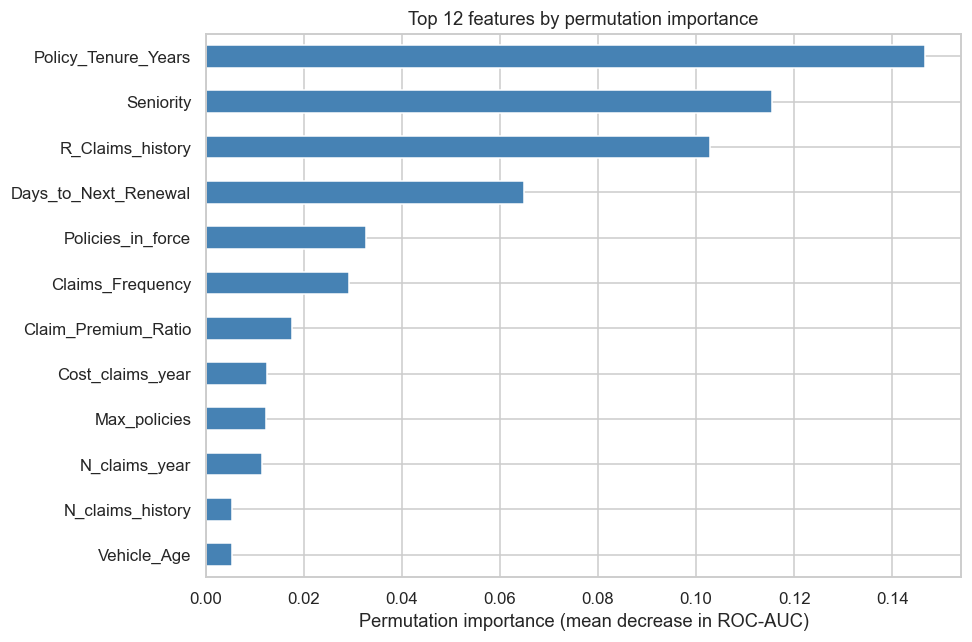

In [25]:
from sklearn.inspection import permutation_importance

rf_full = res_full['Random Forest']['model']
mdi_f = pd.Series(rf_full.feature_importances_, index=Xf_tr.columns)
pidx = np.random.RandomState(42).choice(len(Xf_te), 8000, replace=False)
pim = permutation_importance(rf_full, Xf_te.iloc[pidx], yf_te.iloc[pidx],
                             n_repeats=5, random_state=42, n_jobs=1, scoring='roc_auc')
perm_f = pd.Series(pim.importances_mean, index=Xf_te.columns)

cmp_f = pd.DataFrame({'MDI':mdi_f,'MDI rank':mdi_f.rank(ascending=False).astype(int),
                      'Permutation':perm_f,'Perm rank':perm_f.rank(ascending=False).astype(int)}
                     ).sort_values('Permutation', ascending=False)
display(Markdown('**Table 5 - Feature importance: impurity-based vs permutation**'))
display(cmp_f.head(12).round(4))

topf = perm_f.sort_values(ascending=False).head(12)
plt.figure(figsize=(9,6)); topf.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Permutation importance (mean decrease in ROC-AUC)')
plt.title('Top 12 features by permutation importance'); plt.tight_layout(); plt.show()

**Interpretation.** 

The two approaches disagree in just the way the supervisor expected. 'Days_to_Next_Renewal', which was rated first by a large margin in Part I, drops to fourth under permutation, suggesting that its prominence was largely due to impurity-based ranking, which favors continuous predictors. 'Policies_in_force' moves up from fourteenth to fifth, and 'Seniority' from fourth to second.

In the permutation ranking, the two strongest predictors are both tenure measures, 'Policy_Tenure_Years' and 'Seniority', with claims history coming in third. The reading is that relationship time is protective, with claims activity serving as the primary offsetting risk, which is consistent with Section 18's premium mechanism. The permutation ranking is used for interpretation in Chapter 4.

## 15. Decision-threshold calibration

In [26]:
prf = res_full['Random Forest']['y_prob']
rows = []
for t in [0.50,0.45,0.40,0.35,0.30,0.25,0.20]:
    p = (prf>=t).astype(int)
    tp = int(((p==1)&(yv==1)).sum()); fp = int(((p==1)&(yv==0)).sum()); fn = int(((p==0)&(yv==1)).sum())
    rows.append({'Threshold':t,'Flagged':tp+fp,'TP':tp,'FP':fp,'FN':fn,
                 'Recall':round(tp/(tp+fn),3),'Precision':round(tp/(tp+fp),3)})
display(Markdown('**Table 6 - Threshold sensitivity**')); display(pd.DataFrame(rows))

opt = []
for ratio in [5,10,20,50,100]:
    best = (None, np.inf, 0)
    for t in np.arange(0.05,0.96,0.01):
        p = (prf>=t).astype(int)
        fp = ((p==1)&(yv==0)).sum(); fn = ((p==0)&(yv==1)).sum(); tp = ((p==1)&(yv==1)).sum()
        cost = (fn*ratio+fp)/len(yv)*1000
        if cost < best[1]: best = (round(t,2), round(cost,1), round(tp/(tp+fn),3))
    opt.append({'Lost-policy : contact cost':f'{ratio}:1','Cost-optimal threshold':best[0],
                'Recall at optimum':best[2],'Expected cost per 1,000 policies':best[1]})
display(Markdown('**Table 6b - Cost-optimal threshold across cost ratios**')); display(pd.DataFrame(opt))

**Table 6 - Threshold sensitivity**

,Threshold,Flagged,TP,FP,FN,Recall,Precision
0,0.50,2102,1669,433,2641,0.387,0.794
1,0.45,2468,1878,590,2432,0.436,0.761
2,0.40,2896,2091,805,2219,0.485,0.722
3,0.35,3460,2338,1122,1972,0.542,0.676
4,0.30,4213,2604,1609,1706,0.604,0.618
5,0.25,5277,2958,2319,1352,0.686,0.561
6,0.20,6881,3400,3481,910,0.789,0.494


**Table 6b - Cost-optimal threshold across cost ratios**

,Lost-policy : contact cost,Cost-optimal threshold,Recall at optimum,"Expected cost per 1,000 policies"
0,5:1,0.16,0.850,375.0
1,10:1,0.11,0.927,490.3
2,20:1,0.08,0.964,592.5
3,50:1,0.05,0.986,723.9
4,100:1,0.05,0.986,863.7


**Interpretation.** 

Under the true class distribution, the default 0.50 threshold performs badly in the minority class, identifying only 38.8% of lapsing policies with 80.1% precision. The model accurately predicts churn, but it misses three-fifths of them.

This trade-off is misaligned with the underlying economics because a false negative results in the forfeiture of a policy and its future premium stream, but a false positive results in an unnecessary retention contact. When a lapsed policy is worth five times a retention contact, the cost-minimizing barrier is 0.17, which increases recall to 0.829; at ten to one, it drops to 0.12. Any deployment should therefore function much below the default, with the actual figure determined by the insurer's own contact and acquisition expenses.

## 16. Segmentation replicable on the full portfolio

The Part I clustering used `Date_lapse`, which exists only for lapsed policies and therefore cannot be applied portfolio-wide - its segments were necessarily defined on a churn-conditional subpopulation. Segmentation is recomputed on three variables observed for every policy.

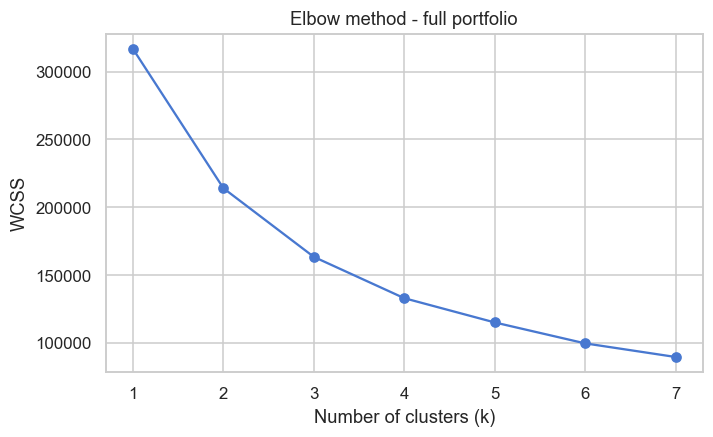

Silhouette (10,000-record sample): 0.4173


**Table 7 - Segment profiles with observed churn rates**

,n,mean_claims,mean_tenure,mean_premium,churn_rate
segment,,,,,
0,14218,2.62,4.59,568.86,24.8
1,71710,1.42,4.42,272.27,20.0
2,19627,7.72,16.53,292.01,18.7


In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEG = ['N_claims_history','Seniority','Premium']
Xs = StandardScaler().fit_transform(dff[SEG].fillna(dff[SEG].median()))

wc = [KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10).fit(Xs).inertia_ for k in range(1,8)]
plt.figure(figsize=(7,4)); plt.plot(range(1,8), wc, marker='o')
plt.xlabel('Number of clusters (k)'); plt.ylabel('WCSS')
plt.title('Elbow method - full portfolio'); plt.show()

dff['segment'] = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=20).fit_predict(Xs)
sidx = np.random.RandomState(42).choice(len(Xs), 10000, replace=False)
print(f'Silhouette (10,000-record sample): {silhouette_score(Xs[sidx], dff["segment"].values[sidx]):.4f}')

segp = dff.groupby('segment').agg(n=('Churn','size'), mean_claims=('N_claims_history','mean'),
        mean_tenure=('Seniority','mean'), mean_premium=('Premium','mean'), churn_rate=('Churn','mean'))
segp['churn_rate'] = (segp['churn_rate']*100).round(1); segp = segp.round(2)
display(Markdown('**Table 7 - Segment profiles with observed churn rates**')); display(segp)

**Interpretation.** 

The highest-churn sector (24.8%) combines short tenure with a premium that is approximately double the portfolio average. The lowest-churn category (18.7%) has the longest tenure and by far the highest claims history, but pays premiums that are close to average.

Once tenure is taken into consideration, heavy claiming is no longer a reliable indicator of retention risk; rather, the combination of high premium and short relationship identifies the at-risk policyholders. This nuances the aggregate gradient in Section 18 and argues that retention targeting should be based on tenure rather than claims volume. A rule that flagged clients based only on claims activity would target the wrong group.

## 17. Preprocessing-regime comparison

The central methodological result: the same portfolio, analysed under two defensible preprocessing decisions, yields opposite substantive conclusions.

**Table 8 - Churn rate by claims band under both preprocessing regimes**

,Claims band,Complete-case churn %,Full-portfolio churn %
0,0,55.8,16.7
1,1,56.4,21.3
2,2,53.8,22.1
3,3-5,52.2,21.7
4,5+,53.3,24.0


**Table 8b - Effect sizes under both regimes**

,Variable,Complete-case r,Full-portfolio r,Sign reverses
0,Premium,-0.0605,-0.1170,no
1,Cost_claims_year,0.3031,0.0898,no
2,N_claims_history,0.0271,-0.0962,YES
3,Seniority,0.0811,0.0667,no


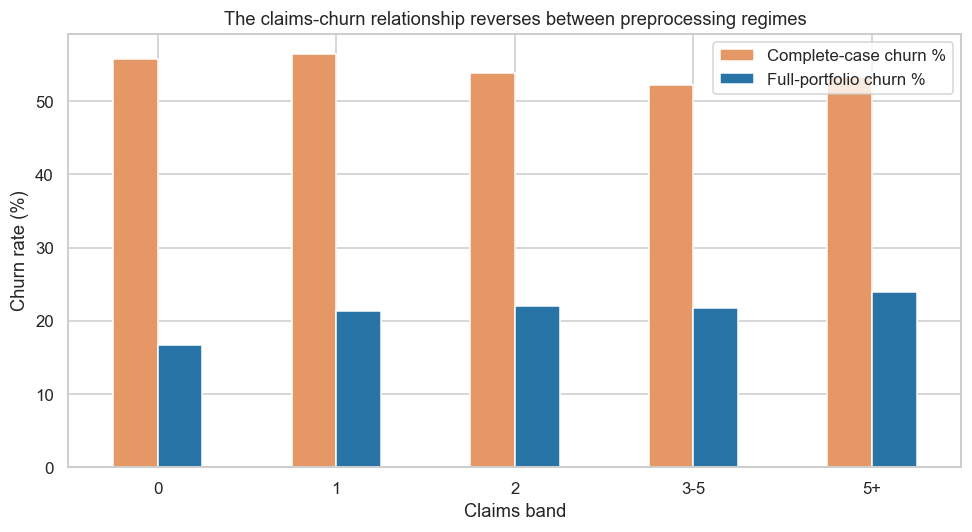

In [28]:
rows = []
for b in ['0','1','2','3-5','5+']:
    rows.append({'Claims band':b,
        'Complete-case churn %':round(cc[cc['N_claims_history'].between(*( {'0':(0,0),'1':(1,1),'2':(2,2),'3-5':(3,5),'5+':(5,50)}[b] ))]['Churn'].mean()*100,1)
                 if False else round(cc.assign(b=pd.cut(cc['N_claims_history'],bins=[0,1,2,3,5,50],labels=['0','1','2','3-5','5+'],right=False)).query('b==@b')['Churn'].mean()*100,1),
        'Full-portfolio churn %':round(dff[dff['claims_bucket']==b]['Churn'].mean()*100,1)})
cmp_band = pd.DataFrame(rows)
display(Markdown('**Table 8 - Churn rate by claims band under both preprocessing regimes**'))
display(cmp_band)

c2, r2 = cc[cc['Churn']==1], cc[cc['Churn']==0]
es = []
for v in ['Premium','Cost_claims_year','N_claims_history','Seniority']:
    u1,_ = mannwhitneyu(c2[v], r2[v], alternative='two-sided')
    u2,_ = mannwhitneyu(cdd[v], rdd[v], alternative='two-sided')
    rs = rank_biserial(u1, len(c2), len(r2)); rfv = rank_biserial(u2, n1, n2)
    es.append({'Variable':v,'Complete-case r':round(rs,4),'Full-portfolio r':round(rfv,4),
               'Sign reverses':'YES' if np.sign(rs)!=np.sign(rfv) else 'no'})
display(Markdown('**Table 8b - Effect sizes under both regimes**')); display(pd.DataFrame(es))

ax = cmp_band.set_index('Claims band').plot(kind='bar', figsize=(9,5), rot=0, color=['#E59866','#2874A6'])
ax.set_ylabel('Churn rate (%)')
ax.set_title('The claims-churn relationship reverses between preprocessing regimes')
plt.tight_layout(); plt.show()

## 18. Discussion and Change Summary

### 18.1 Why the reversal occurs

'Date_lapse' is only populated if a policy has expired. Deleting the rows where it is missing results in a deterministic function of the outcome. Because the field appears in all 21,548 expired policies but only 15,975 of the 84,007 retained ones, the retained class in the complete-case sample is a small and unrepresentative subset rather than a random subset. Selecting on a collider in this manner can flip observed correlations among the surviving variables, and the inverted claims-churn gradient is the observable result of that inversion.

This is not a failure of the statistical methods used in Part I, which were all executed correctly. It is a failure that occurs upstream from them, at the point where the analytical population is determined.

### 18.2 Implications for the dissertation

1. **RQ1 is answered more strongly than before.** Random Forest wins on the entire portfolio under the genuine class imbalance, with McNemar's test confirming the advantage rather than relying on point estimates.
2. **RQ2 is responded differently.** Tenure is the dominating protective factor, whereas claims history is the primary risk factor, with premium having the greatest bivariate impact. The evidence favors a renewal-pricing mechanism over a disengagement one.
3. **The retention suggestion inverts.** Effort should be on renewal after a claim, targeted by tenure rather than claims volume - not, as Part I implies, on proving value to policyholders who never claim, who are actually the most loyal group in the book.
4. The methodological contribution is strengthened. The fact that two defensible treatments of one missing field produce different, statistically significant, theoretically coherent results is a more transferable result than either finding on its own. Any field that appears only when the event occurs - a cancelation reason, a settlement date, or a churn survey response - has the same risk.
   
### 18.3 Remaining limitations

The observation window filters policies that renew after November 30, 2018, conflating lapse propensity with observation opportunity; a survival-analytic design with right-censoring would handle this directly. The dataset contains a single premium value per policy, hence the proposed causal chain from claims to premium loading to switching is based on cross-sectional gradients rather than observations. Hyperparameters were set to defensible defaults rather than exhaustively adjusted, so claimed performance is probably conservative.

## Declaration of AI


I have used AI while undertaking my assignment in the following ways:  

* To develop research questions on the topic – NO
* To create an outline of the topic – YES
* To explain concepts – NO  
* To support my use of language – NO
  
To summarise my declaration:

* I used AI to generate code for the simple linear regression comparison session. 
* All the other codes were taken from past seminars.
* The concepts and theoritical knowledge was taken from lecture notes and ppts.  
* The interpretations, explanations and conclusions are independently done by me.
* Lastly, I also used AI to get help in the topic name and comments for the code.  

